<a href="https://colab.research.google.com/github/degasbr1964/Tech-Challenge-Fase-1/blob/main/Tech_Challenge_Fase_1_Edgar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xlrd

Como melhorar o NPS das vendas online da empresa. Porque o usuário se torna detrator ou promotor da empresa.

In [2]:
# Libs - bibliotecas de exploração e manipulação de dados
import pandas as pd
import numpy as np

# Libs Gráficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Avisos
import warnings
warnings.filterwarnings("ignore")

In [5]:
nps = pd.read_csv("desafio_nps_fase_1.csv")

In [ ]:
nps.head(20)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


# Tamanho da base de dados

In [6]:
nps.shape

(2500, 19)

In [7]:
print(f'A base de dados possui {nps.shape[0]} linhas e {nps.shape[1]} colunas')

A base de dados possui 2500 linhas e 19 colunas


Verificar o tipo das colunas

In [8]:
nps.dtypes

,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64


Existem valores nulos?

In [9]:
nps.isnull().sum().sum()

np.int64(0)

Não existem valores nulos

In [10]:
nps.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

Cria uma base com menos colunas

In [11]:
df_nps = nps[['customer_age', 'customer_region',
       'customer_tenure_months', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score']]

In [12]:
df_nps.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


##Gerando uma amostra da base inicial

In [14]:
np.random.seed(42)
amostra = df_nps.sample(n=1000,replace=False)

In [15]:
amostra.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
1447,42,Nordeste,107,435.57,4,85.36,10,3,1,43.82,3,1,7,6.8,0,4,3.7
1114,24,Sudeste,118,1110.66,5,20.14,9,6,2,31.05,3,0,5,6.0,0,2,3.8
1064,49,Norte,26,395.12,6,133.66,8,5,0,40.72,2,0,8,8.3,1,0,4.6
2287,35,Sudeste,80,418.01,3,3.68,6,4,2,36.99,3,0,8,5.3,0,5,3.6
1537,42,Sul,102,908.39,4,26.94,9,4,1,44.67,1,1,2,6.8,0,2,6.3


In [16]:
nps.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [17]:
amostra.describe()

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.60600,61.172000,427.632220,3.484000,29.190100,6.096000,7.983000,2.198000,38.661090,1.995000,1.530000,5.365000,4.416800,0.091000,4.152000,2.999200
std,14.76451,34.645616,287.971102,1.699009,29.219433,3.098126,3.809623,1.452896,11.912231,0.810946,1.197721,3.468401,2.512782,0.287753,1.752703,2.388213
min,18.00000,1.000000,14.580000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.00000,31.000000,214.300000,2.000000,8.327500,3.000000,5.000000,1.000000,30.642500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.800000
50%,43.00000,62.000000,368.285000,3.000000,20.190000,6.000000,8.000000,2.000000,38.550000,2.000000,1.000000,5.000000,4.300000,0.000000,4.000000,2.800000
75%,56.00000,89.000000,569.817500,5.000000,40.772500,9.000000,11.000000,3.000000,46.557500,3.000000,2.000000,8.000000,6.200000,0.000000,5.000000,4.800000
max,69.00000,119.000000,1983.810000,6.000000,207.470000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


Altera os nomes das colunas para português

In [18]:
df_nps.columns = ['idade', 'regiao', 'tempo_relacionamento','valor_compra','quantidade','desconto', 'parcelas','tempo_entrega', 'dias_atraso','valor_frete', 'tentativas_entrega', 'chamados_sac','tempo_resolucao','nps','recompra_30d','num_reclamacoes', 'csat']

Estatística descritiva

<Axes: >

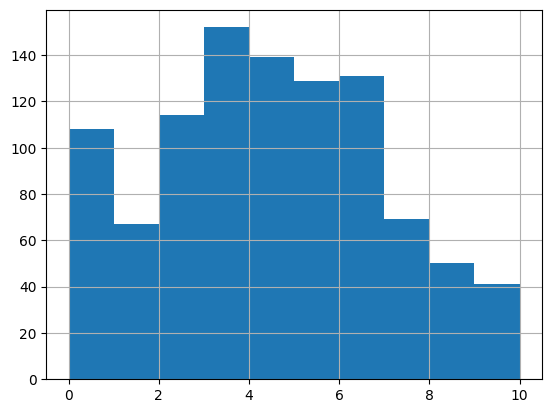

In [19]:
amostra['nps_score'].hist()

In [25]:
amostra.describe().round(2)

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,43.61,61.17,427.63,3.48,29.19,6.1,7.98,2.20,38.66,2.00,1.53,5.36,4.42,0.09,4.15,3.00
std,14.76,34.65,287.97,1.70,29.22,3.1,3.81,1.45,11.91,0.81,1.20,3.47,2.51,0.29,1.75,2.39
min,18.00,1.00,14.58,1.00,0.02,1.0,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,214.30,2.00,8.33,3.0,5.00,1.00,30.64,1.00,1.00,2.00,2.60,0.00,3.00,0.80
50%,43.00,62.00,368.28,3.00,20.19,6.0,8.00,2.00,38.55,2.00,1.00,5.00,4.30,0.00,4.00,2.80
75%,56.00,89.00,569.82,5.00,40.77,9.0,11.00,3.00,46.56,3.00,2.00,8.00,6.20,0.00,5.00,4.80
max,69.00,119.00,1983.81,6.00,207.47,11.0,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [37]:
def nps_class(nps_score):
    if nps_score <= 6:
        return "Detrator"
    elif nps_score >= 9:
        return "Promotor"
    else:
        return "Passivo"

Classificação do cliente segundo o NPS
(fonte: Bain & Company)

*   Promotores (9-10)
*   Passivos (7-8)
*   Detratores (0-6)








In [38]:
amostra.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
1447,42,Nordeste,107,435.57,4,85.36,10,3,1,43.82,3,1,7,6.8,0,4,3.7
1114,24,Sudeste,118,1110.66,5,20.14,9,6,2,31.05,3,0,5,6.0,0,2,3.8
1064,49,Norte,26,395.12,6,133.66,8,5,0,40.72,2,0,8,8.3,1,0,4.6
2287,35,Sudeste,80,418.01,3,3.68,6,4,2,36.99,3,0,8,5.3,0,5,3.6
1537,42,Sul,102,908.39,4,26.94,9,4,1,44.67,1,1,2,6.8,0,2,6.3


## *Função para classificar NPS*

In [42]:
amostra["nps_class"] = amostra["nps_score"].apply(nps_class)


In [43]:
amostra.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_class
1447,42,Nordeste,107,435.57,4,85.36,10,3,1,43.82,3,1,7,6.8,0,4,3.7,Passivo
1114,24,Sudeste,118,1110.66,5,20.14,9,6,2,31.05,3,0,5,6.0,0,2,3.8,Detrator
1064,49,Norte,26,395.12,6,133.66,8,5,0,40.72,2,0,8,8.3,1,0,4.6,Passivo
2287,35,Sudeste,80,418.01,3,3.68,6,4,2,36.99,3,0,8,5.3,0,5,3.6,Detrator
1537,42,Sul,102,908.39,4,26.94,9,4,1,44.67,1,1,2,6.8,0,2,6.3,Passivo


In [ ]:
df_nps['recompra_30d'].value_counts()

,count
recompra_30d,
0,2282
1,218


### Análise de médias por classificação de NPS para identificar motivos de NPS baixo

In [ ]:
nps_grouped_analysis = df_nps.groupby('classificacao_nps').mean(numeric_only=True).round(2)
display(nps_grouped_analysis.sort_values(by='nps'))

,idade,tempo_relacionamento,valor_compra,quantidade,desconto,parcelas,tempo_entrega,dias_atraso,valor_frete,tentativas_entrega,chamados_sac,tempo_resolucao,nps,recompra_30d,num_reclamacoes,csat
classificacao_nps,,,,,,,,,,,,,,,,
Detrator,43.31,61.58,428.99,3.49,29.63,5.97,8.00,2.53,38.40,1.99,1.69,5.79,3.26,0.0,4.62,2.34
Passivo,43.65,60.11,445.47,3.35,29.53,6.17,8.13,1.29,37.82,2.02,1.09,4.79,7.16,0.2,2.91,4.37
Promotor,43.63,63.00,468.08,3.64,32.75,5.81,7.94,0.72,37.05,2.15,0.67,3.70,9.61,1.0,2.27,6.04


Com a tabela acima, podemos comparar as médias de diversas métricas para cada grupo de NPS. Fatores com valores significativamente maiores para 'Detrator' e menores para 'Promotor' são os potenciais maiores motivadores de um NPS baixo.

Quanto maior os dias de atraso, o tempo de resolução, os chamados ao SAC, o número de reclamações, menor o NPS e consequentemente torna esses clientes detratores da empresa.

In [ ]:
pedidos_atrasados_por_regiao = df_nps[df_nps['dias_atraso'] > 0].groupby('regiao').size().reset_index(name='pedidos_atrasados')
display(pedidos_atrasados_por_regiao)

,regiao,pedidos_atrasados
0,Centro-Oeste,410
1,Nordeste,437
2,Norte,445
3,Sudeste,473
4,Sul,458


Como podemos ver, os atrasos de entrega independem da regiaão, portanto não é um problema localizado, e sim da logística como um todo.

In [ ]:
detratores_com_atraso = df_nps[(df_nps['classificacao_nps'] == 'Detrator') & (df_nps['dias_atraso'] > 0)]
num_detratores_com_atraso = detratores_com_atraso.shape[0]
print(f"O número de Detratores que tiveram atraso na entrega é: {num_detratores_com_atraso}")

O número de Detratores que tiveram atraso na entrega é: 1750


In [ ]:
detratores_com_reclamacao = df_nps[(df_nps['classificacao_nps'] == 'Detrator') & (df_nps['num_reclamacoes'] > 0)]
num_detratores_com_reclamacao = detratores_com_reclamacao.shape[0]
print(f"O número de Detratores que fizeram reclamação é: {num_detratores_com_reclamacao}")

O número de Detratores que fizeram reclamação é: 1850


In [ ]:
total_detratores = df_nps[df_nps['classificacao_nps'] == 'Detrator'].shape[0]
detratrores_atraso_reclamacao = df_nps[(df_nps['classificacao_nps'] == 'Detrator') & (df_nps['dias_atraso'] > 0) & (df_nps['num_reclamacoes'] > 0)]
num_detratores_atraso_reclamacao = detratrores_atraso_reclamacao.shape[0]

if total_detratores > 0:
    porcentagem_detratores_atraso_reclamacao = (num_detratores_atraso_reclamacao / total_detratores) * 100
    print(f"Do total de Detratores, {porcentagem_detratores_atraso_reclamacao:.2f}% tiveram atraso na entrega e fizeram reclamação.")
else:
    print("Não há detratores na base de dados para realizar o cálculo.")

Do total de Detratores, 94.54% tiveram atraso na entrega e fizeram reclamação.


94,54% dos clientes que tiveram atraso na entrega, fizeram reclamação ao SAC, isso nos leva a acreditar que diminuindo os problemas de logística diminuiremos os atendimentos no SAC.

In [ ]:
detratores_reclamacao_sem_atraso = df_nps[(df_nps['classificacao_nps'] == 'Detrator') & (df_nps['num_reclamacoes'] > 0) & (df_nps['dias_atraso'] == 0)]
num_detratores_reclamacao_sem_atraso = detratores_reclamacao_sem_atraso.shape[0]
print(f"O número de Detratores que fizeram reclamação e não tiveram atraso na entrega é: {num_detratores_reclamacao_sem_atraso}")

O número de Detratores que fizeram reclamação e não tiveram atraso na entrega é: 100


Os detratores que não tiveram problemas na entrega é pequeno, e pode ser tratado por um atendimento personalizado para descobrir o que motivou isso.

In [ ]:
promotores_com_atraso = df_nps[(df_nps['classificacao_nps'] == 'Promotor') & (df_nps['dias_atraso'] > 0)]
num_promotores_com_atraso = promotores_com_atraso.shape[0]
print(f"O número de Promotores que tiveram atraso na entrega é: {num_promotores_com_atraso}")

O número de Promotores que tiveram atraso na entrega é: 60
